# Plant Disease Detection CNN

This notebook shows how to build and train a convolutional neural network for plant disease classification.

## 1. Install dependencies

Make sure you have installed the packages from `../requirements.txt`.

In [7]:
!pip install tensorflow
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

print('TensorFlow version:', tf.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 771.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 101.5 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


TensorFlow version: 2.21.0


## 2. Dataset paths



## 2.1 Download and Extract Dataset from Kaggle

We will download the `emmarex/plantdisease` dataset from Kaggle. You will need to upload your `kaggle.json` API token to your Colab environment for authentication. This file should contain your Kaggle username and API key.


In [ ]:
%pip install kaggle

!mkdir -p ~/.kaggle

!cp /content/kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [9]:
# Download the dataset
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
plantdisease.zip: Skipping, found more recently modified local copy (use --force to force download)


In [10]:
# Unzip the dataset into a dedicated directory
import zipfile
import os

zip_file_path = 'plantdisease.zip'
extract_dir = '/content/plant-disease-data'

if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Dataset extracted to: {extract_dir}")

# Verify extraction by listing contents
print("Extracted contents:")
!ls -R {extract_dir}

Streaming output truncated to the last 5000 lines.
'ff20d775-59a6-437c-9039-f72d07aa4484___Com.G_SpM_FL 8524.JPG'
'ff6346ca-227b-4cb4-a350-0941048744fa___Com.G_SpM_FL 9338.JPG'
'ff9a52b5-b200-4f23-9e0d-629b1a0e89db___Com.G_SpM_FL 8634.JPG'
'ffb00771-1462-4c9d-962b-7aaa7e8d5a51___Com.G_SpM_FL 1411.JPG'
'ffb50767-1893-4379-ba42-8af6d8030057___Com.G_SpM_FL 8854.JPG'
'ffcfa32d-4506-49ed-9e35-972d5cbad0b8___Com.G_SpM_FL 8450.JPG'
'fff3aeaf-d4ae-4f3a-86d9-79237d07270f___Com.G_SpM_FL 9349.JPG'
'fff8949b-3721-4f42-a489-8d39753fe7bb___Com.G_SpM_FL 8656.JPG'

/content/plant-disease-data/PlantVillage/Tomato__Target_Spot:
'002213fb-b620-4593-b9ac-6a6cc119b100___Com.G_TgS_FL 8360.JPG'
'003a5321-0430-42dd-a38d-30ac4563f4ba___Com.G_TgS_FL 8121.JPG'
'0044d10f-7062-4655-8abd-9fffc5b2f152___Com.G_TgS_FL 7908.JPG'
'007ec913-8cfe-43ed-b458-f041a17266ae___Com.G_TgS_FL 9844.JPG'
'00854623-ba28-446d-a1d5-03c0ae3f99d9___Com.G_TgS_FL 7949.JPG'
'0118c27a-f34a-41e1-8b2f-d2c564f83c5c___Com.G_TgS_FL 0013.JPG'
'011

## 2.2 Define Dataset Paths

Now that the dataset is extracted, we define the `train_dir` and `test_dir` based on its structure.


In [ ]:
import os

extract_dir = '/content/plant-disease-data' # This is where the zip was extracted

# Find the actual root directory containing class folders
# It's usually a single directory inside the extracted path, or specifically 'PlantVillage'
potential_root_dirs = [d for d in os.listdir(extract_dir) if os.path.isdir(os.path.join(extract_dir, d))]

data_root_dir = None
if 'PlantVillage' in potential_root_dirs:
    # Prioritize 'PlantVillage' if it's explicitly found
    data_root_dir = os.path.join(extract_dir, 'PlantVillage')
elif len(potential_root_dirs) == 1:
    # If there's only one directory, assume it's the root
    data_root_dir = os.path.join(extract_dir, potential_root_dirs[0])
else:
    print(f"Error: Could not determine data root directory in {extract_dir}. Found: {potential_root_dirs}")

if data_root_dir and os.path.exists(data_root_dir):
    print('Data root directory:', data_root_dir)
    print('Classes found:', sorted(os.listdir(data_root_dir)))
else:
    print(f"Error: Data root directory not found or invalid. Checked path: {data_root_dir}")



Data root directory: /content/plant-disease-data/PlantVillage
Classes found: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


Image count per class:
  Pepper__bell___Bacterial_spot: 997
  Pepper__bell___healthy: 1478
  Potato___Early_blight: 1000
  Potato___Late_blight: 1000
  Potato___healthy: 152
  Tomato_Bacterial_spot: 2127
  Tomato_Early_blight: 1000
  Tomato_Late_blight: 1909
  Tomato_Leaf_Mold: 952
  Tomato_Septoria_leaf_spot: 1771
  Tomato_Spider_mites_Two_spotted_spider_mite: 1676
  Tomato__Target_Spot: 1404
  Tomato__Tomato_YellowLeaf__Curl_Virus: 3209
  Tomato__Tomato_mosaic_virus: 373
  Tomato_healthy: 1591


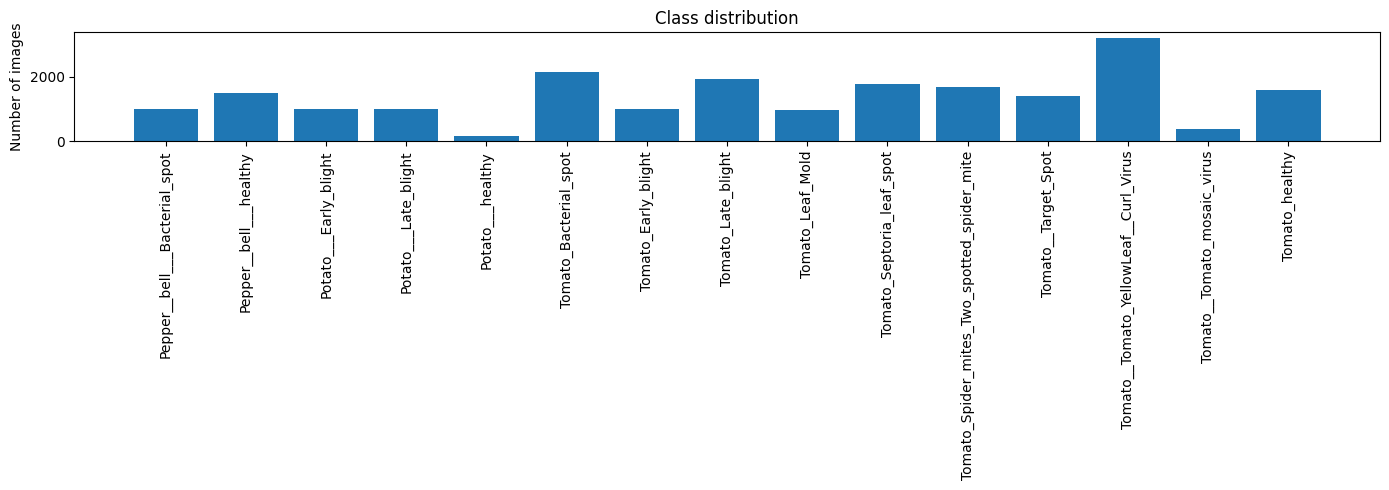

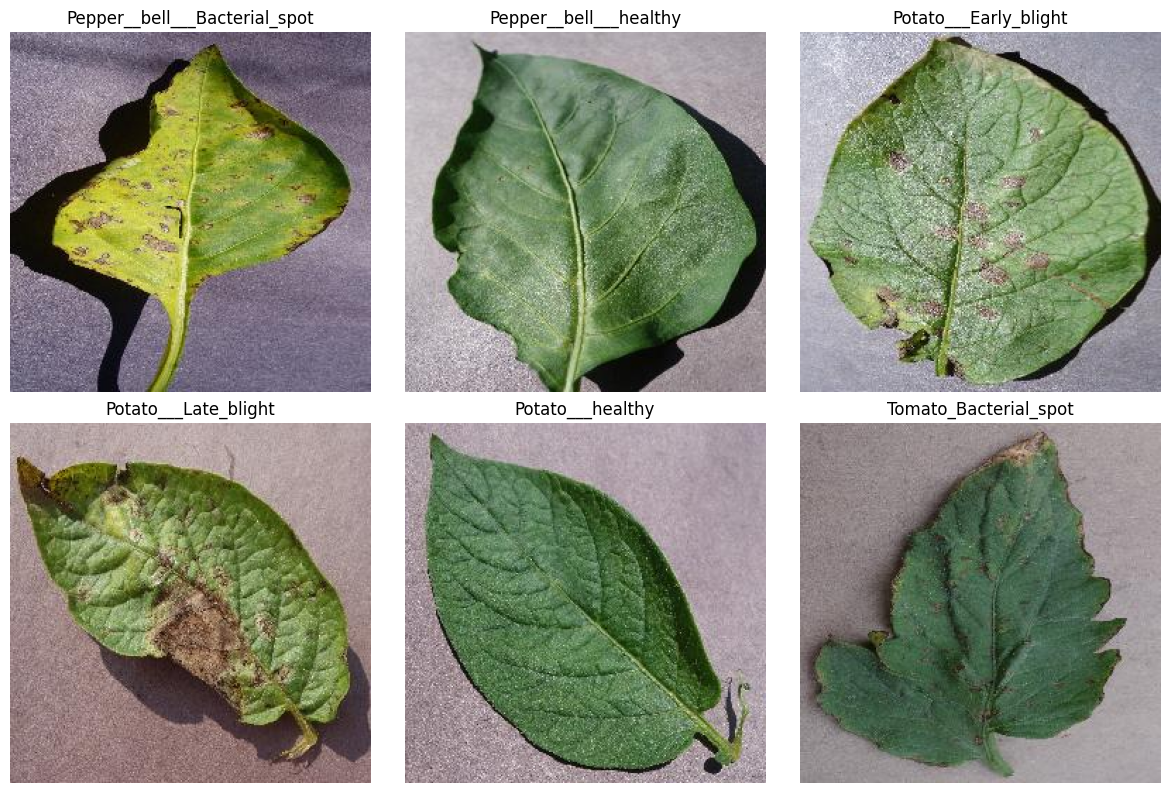

In [12]:
import pathlib

# Dataset exploration: counts and sample images

data_root = pathlib.Path(data_root_dir)

class_counts = {}
for class_dir in sorted(data_root.iterdir()):
    if class_dir.is_dir():
        class_counts[class_dir.name] = len(list(class_dir.glob('*')))

print('Image count per class:')
for class_name, count in class_counts.items():
    print(f'  {class_name}: {count}')

plt.figure(figsize=(14, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title('Class distribution')
plt.ylabel('Number of images')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sample_classes = list(class_counts.keys())[:6]
for idx, cls in enumerate(sample_classes, 1):
    image_files = list((data_root / cls).glob('*'))
    if not image_files:
        continue
    img = plt.imread(str(image_files[0]))
    ax = plt.subplot(2, 3, idx)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Create training and validation datasets

We use `image_dataset_from_directory` to load images and automatically infer class labels.

In [ ]:
import tensorflow as tf

batch_size = 32
img_height = 224
img_width = 224


# Configure for performance
AUTOTUNE = tf.data.AUTOTUNE

# Use a fixed seed for reproducibility across splits
split_seed = 123

# --- Create the training dataset (80% of total) ---
# `validation_split=0.2` means 20% is reserved for validation/test,
# so 'training' gets the remaining 80%.
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_root_dir,
    labels='inferred',
    label_mode='categorical',
    batch_size=batch_size,
    image_size=(img_height, img_width),
    shuffle=True,
    seed=split_seed,
    validation_split=0.2, # 80% for training, 20% for combined val/test
    subset='training'
)

# --- Create a combined validation + test dataset (remaining 20% of total) ---
# This part gets the 20% that was split off by `validation_split=0.2`.
val_test_dataset = tf.keras.utils.image_dataset_from_directory(
    data_root_dir,
    labels='inferred',
    label_mode='categorical',
    batch_size=batch_size,
    image_size=(img_height, img_width),
    shuffle=True, # Shuffle for random split below
    seed=split_seed,
    validation_split=0.2,
    subset='validation'
)

# --- Split the val_test_dataset (20%) into validation (10%) and test (10%) ---
# val_test_dataset represents 20% of the total data.
# To get 10% for validation and 10% for test, we split val_test_dataset 50/50.

# tf.data.experimental.cardinality returns the number of batches if `batch_size` is set.
# We need to get the total number of elements in the `val_test_dataset`.
total_val_test_batches = tf.data.experimental.cardinality(val_test_dataset).numpy()
num_val_batches = total_val_test_batches // 2 # Take half for validation

validation_dataset = val_test_dataset.take(num_val_batches)
test_dataset = val_test_dataset.skip(num_val_batches)

class_names = train_dataset.class_names
num_classes = len(class_names)

print('Classes:', class_names)
print(f'Total number of classes: {num_classes}')
print(f'Number of training batches: {tf.data.experimental.cardinality(train_dataset).numpy()}')
print(f'Number of validation batches: {tf.data.experimental.cardinality(validation_dataset).numpy()}')
print(f'Number of test batches: {tf.data.experimental.cardinality(test_dataset).numpy()}')

# Optimize datasets for performance before augmentation
train_dataset = train_dataset.cache()
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# Data augmentation pipeline for the training set
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
)
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)


Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Total number of classes: 15
Number of training batches: 516
Number of validation batches: 64
Number of test batches: 65


## 4. Visualize sample images

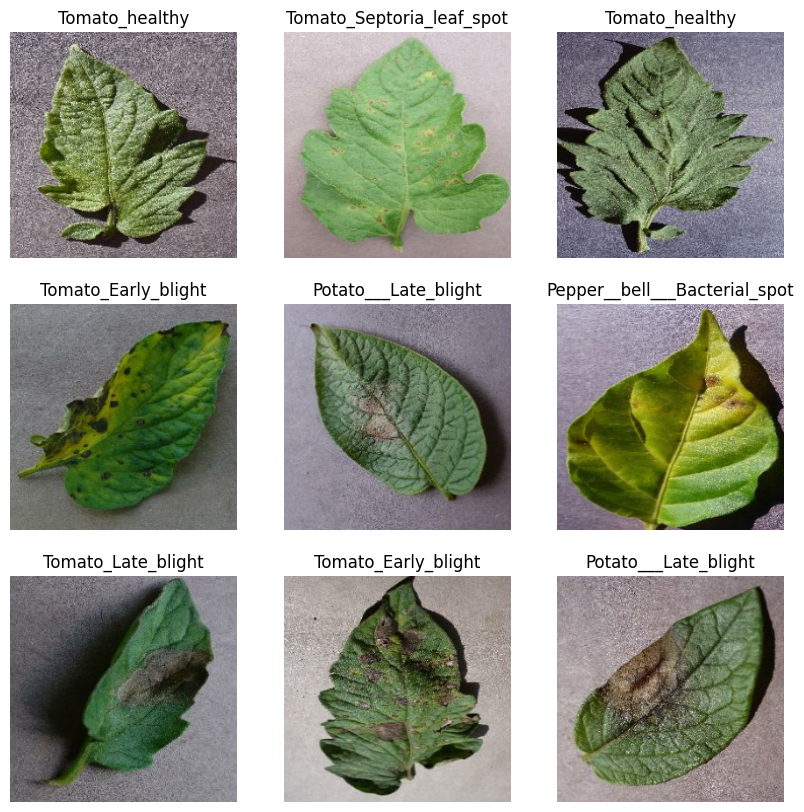

In [14]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(min(9, images.shape[0])):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis('off')
plt.show()

## 5. Build the CNN model

In [15]:
num_classes = len(class_names)

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,895 (42.61 MB)

 Trainable params: 11,170,895 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the model with Early Stopping

In [ ]:
epochs = 20

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs,
    callbacks=[early_stopping]
)


Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 650s 1s/step - accuracy: 0.4740 - loss: 1.6429 - val_accuracy: 0.7549 - val_loss: 0.7452
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 634s 1s/step - accuracy: 0.7166 - loss: 0.8516 - val_accuracy: 0.8296 - val_loss: 0.4926
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 635s 1s/step - accuracy: 0.7808 - loss: 0.6494 - val_accuracy: 0.8359 - val_loss: 0.4890
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 636s 1s/step - accuracy: 0.8175 - loss: 0.5365 - val_accuracy: 0.8872 - val_loss: 0.3398
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 634s 1s/step - accuracy: 0.8370 - loss: 0.4808 - val_accuracy: 0.8652 - val_loss: 0.3780
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 635s 1s/step - accuracy: 0.8684 - loss: 0.3831 - val_accuracy: 0.8887 - val_loss: 0.3152
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 636s 1s/step - accuracy: 0.8885 - loss: 0.3246 - val_accuracy: 0.9106 - val_loss: 0.2817
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 635s 1s/step - accuracy: 0.9012 - loss: 0.2855 - val_accu

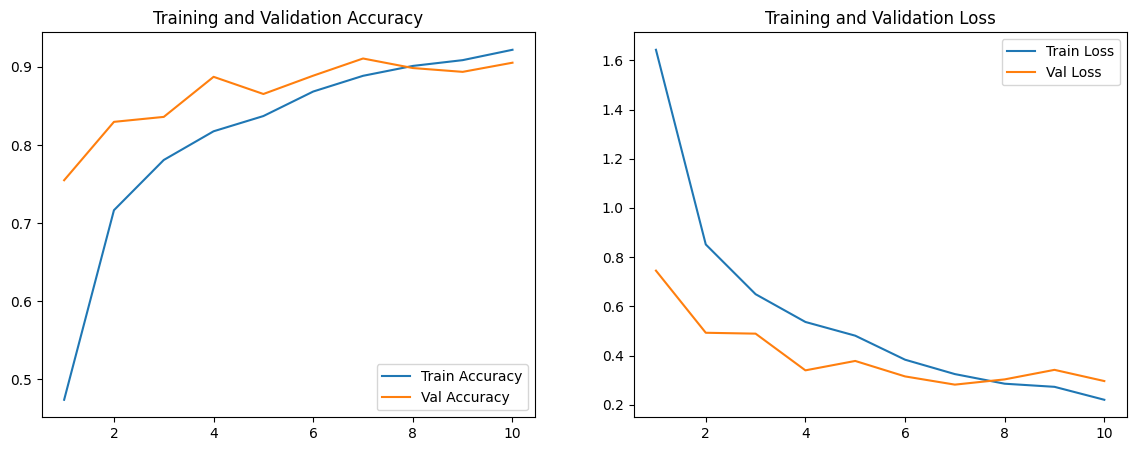

In [17]:
# Plot training and validation metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## 8. Evaluate model on Test Set

In [18]:
print('Evaluating model on the test dataset...')
loss, accuracy = model.evaluate(test_dataset)

print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

Evaluating model on the test dataset...
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 297ms/step - accuracy: 0.9163 - loss: 0.3807
Test Loss: 0.3807
Test Accuracy: 0.9163


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

<Figure size 1200x1200 with 0 Axes>

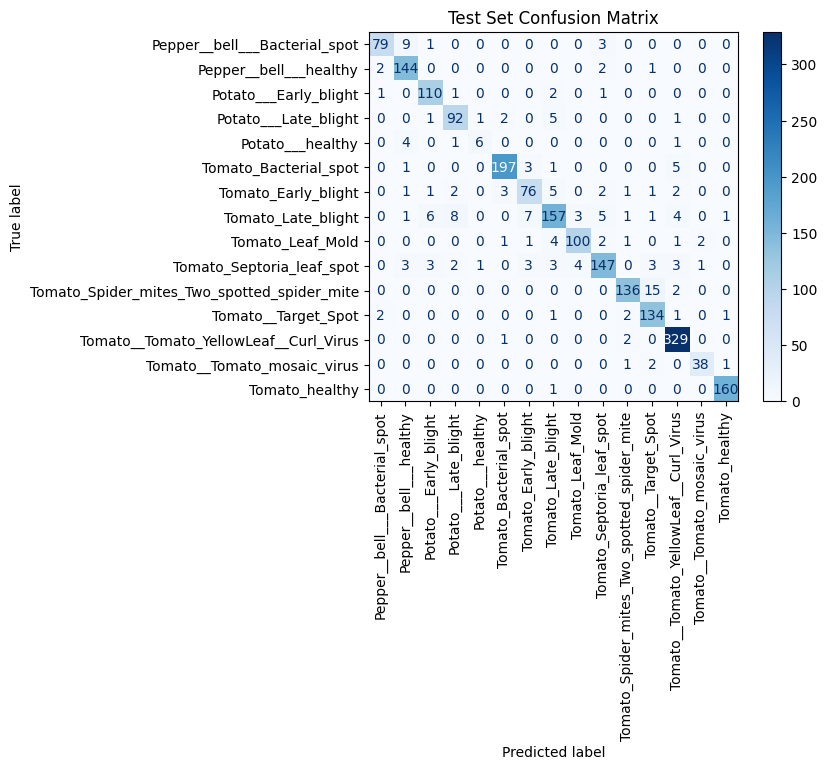

In [19]:
# Confusion matrix on the test set
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []
for images, labels in test_dataset:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(12, 12))
disp.plot(cmap='Blues', xticks_rotation='vertical', values_format='d')
plt.title('Test Set Confusion Matrix')
plt.show()